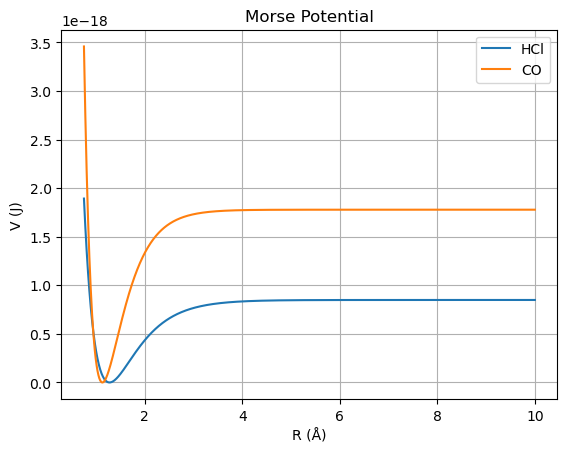

In [ ]:
#code out Morse potential
import numpy as np

def morse_potential(R_A, De_eV, a_Ainv, Re_A):
    """
    Morse potential V(R) in Joules.

    Parameters
    ----------
    R_A    : array_like
        Internuclear distance grid in Angstrom.
    De_eV  : float
        Dissociation energy D_e in eV.
    a_Ainv : float
        Morse range parameter a in Angstrom^-1.
    Re_A   : float
        Equilibrium bond length R_e in Angstrom.
    """
    EV_TO_J = 1.60218e-19  # eV to Joules conversion factor
    De_J = De_eV * EV_TO_J
    return De_J * (1.0 - np.exp(-a_Ainv * (R_A - Re_A)))**2


#now plot it for both HCl and CO
import matplotlib.pyplot as plt

R_A = np.linspace(0.75, 10, 1000)
De_eV_HCl =5.3
De_eV_CO = 11.1
a_Ainv_HCl = 1.74 # Å^-1
a_Ainv_CO = 2.31 # Å^-1
Re_A_HCl = 1.275 # Å
Re_A_CO = 1.128 # Å

V_HCl = morse_potential(R_A, De_eV_HCl, a_Ainv_HCl, Re_A_HCl)
V_CO = morse_potential(R_A, De_eV_CO, a_Ainv_CO, Re_A_CO)

#plot both
plt.plot(R_A, V_HCl, label="HCl")
plt.plot(R_A, V_CO, label="CO")
plt.xlabel("R (Å)")
plt.ylabel("V (J)")
plt.title("Morse Potential")
plt.legend()
plt.grid()
plt.show()

# set plot to show wells better

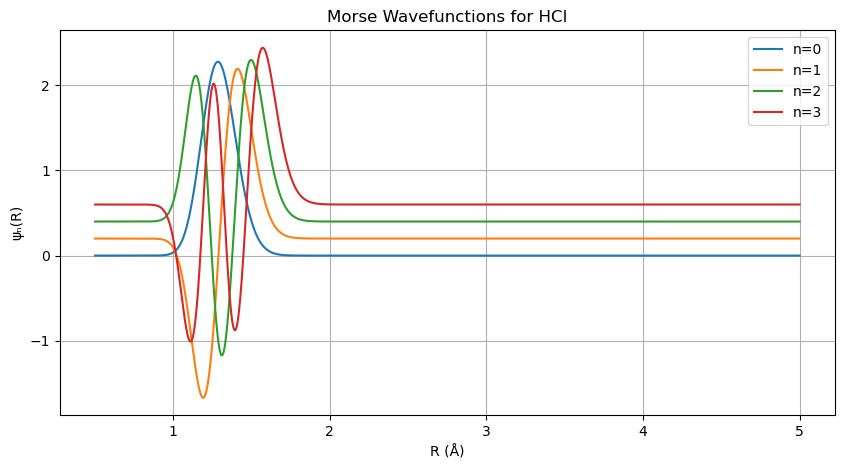

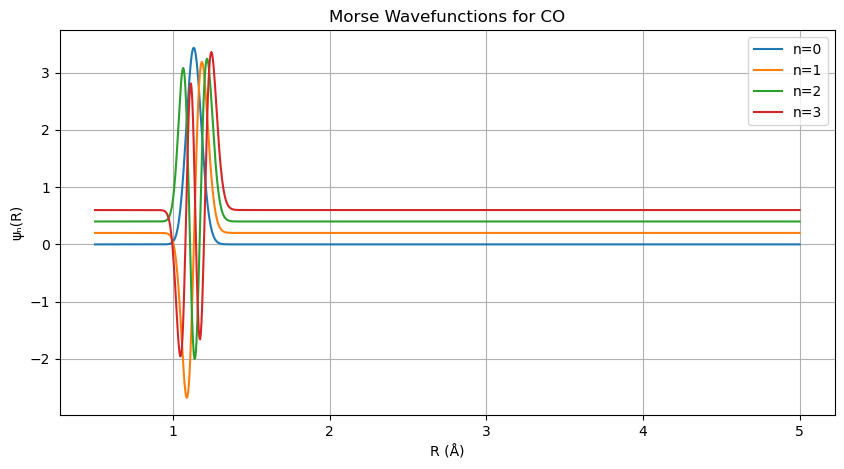

Text(0.5, 0.01, 'Note: Wavefunctions are shifted vertically for clarity.')

<Figure size 640x480 with 0 Axes>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import genlaguerre

# --- Constants ---
HBAR = 1.0545718e-34      # J·s
AMU_TO_KG = 1.66054e-27   # kg
EV_TO_J = 1.60218e-19     # J
ANGSTROM_TO_M = 1e-10     # m

# --- Reduced masses (amu) ---
mu_HCl = (1.0 * 35.45) / (1.0 + 35.45)
mu_CO  = (12.0 * 16.0) / (12.0 + 16.0)

def morse_wavefunction(n, R_A, De_eV, a_Ainv, Re_A, mu_amu):
    """
    Morse wavefunction ψ_n(R) for vibrational level n.
    Properly normalized (numerically).
    """
    # Unit conversions
    De_J = De_eV * EV_TO_J
    mu = mu_amu * AMU_TO_KG
    a_m = a_Ainv / ANGSTROM_TO_M  # Å^-1 → m^-1

    # Morse parameter λ
    lambda_ = np.sqrt(2 * mu * De_J) / (a_m * HBAR)

    # Max allowed bound state
    n_max = int(lambda_ - 0.5)
    if n > n_max:
        return None  # skip invalid states cleanly

    # Dimensionless variables
    s_n = lambda_ - n - 0.5
    y = 2 * lambda_ * np.exp(-a_Ainv * (R_A - Re_A))  # stays dimensionless

    # Laguerre polynomial
    L_n_alpha = genlaguerre(n, 2 * s_n)

    # Wavefunction
    psi_n = np.exp(-y / 2) * y**s_n * L_n_alpha(y)

    # Normalize numerically
    norm = np.trapezoid(psi_n**2, R_A)
    psi_n /= np.sqrt(norm)

    return psi_n

R_A = np.linspace(0.5, 5.0, 1000)

De_eV_HCl = 5.3
a_Ainv_HCl = 1.74 # Å^-1
Re_A_HCl = 1.275 # Å

De_eV_CO = 11.1
a_Ainv_CO = 2.31 # Å^-1
Re_A_CO = 1.128 # Å

# --- Plot HCl ---
plt.figure(figsize=(10, 5))
for n in range(4):
    psi = morse_wavefunction(n, R_A, De_eV_HCl, a_Ainv_HCl, Re_A_HCl, mu_HCl)
    if psi is not None:
        plt.plot(R_A, psi + n*0.2, label=f"n={n}")

plt.xlabel("R (Å)")
plt.ylabel("ψₙ(R)")
plt.title("Morse Wavefunctions for HCl")
plt.legend()
plt.grid()
plt.show()

# --- Plot CO ---
plt.figure(figsize=(10, 5))
for n in range(4):
    psi = morse_wavefunction(n, R_A, De_eV_CO, a_Ainv_CO, Re_A_CO, mu_CO)
    if psi is not None:
        plt.plot(R_A, psi + n*0.2, label=f"n={n}")

plt.xlabel("R (Å)")
plt.ylabel("ψₙ(R)")
plt.title("Morse Wavefunctions for CO")
plt.legend()
plt.grid()
plt.show()

#Adjust legend to show that plots shifted vertically for clarity.
plt.figtext(0.5, 0.01, "Note: Wavefunctions are shifted vertically for clarity.", ha="center", fontsize=10)